In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0

11490434/11490434 [==============================] - 37s 3us/step


In [3]:
def build_model():
    model = Sequential([
        Input(shape=(28,28,1)),
        Conv2D(32,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128,activation='relu'),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [4]:
model1 = build_model()
history1 = model1.fit(x_train, y_train, epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 [==============================] - 43s 22ms/step - loss: 0.1290 - accuracy: 0.9604 - val_loss: 0.0455 - val_accuracy: 0.9848
Epoch 2/5
1875/1875 [==============================] - 37s 20ms/step - loss: 0.0444 - accuracy: 0.9863 - val_loss: 0.0412 - val_accuracy: 0.9867
Epoch 3/5
1875/1875 [==============================] - 36s 19ms/step - loss: 0.0294 - accuracy: 0.9907 - val_loss: 0.0300 - val_accuracy: 0.9900
Epoch 4/5
1875/1875 [==============================] - 35s 19ms/step - loss: 0.0206 - accuracy: 0.9932 - val_loss: 0.0298 - val_accuracy: 0.9911
Epoch 5/5
1875/1875 [==============================] - 37s 20ms/step - loss: 0.0156 - accuracy: 0.9950 - val_loss: 0.0336 - val_accuracy: 0.9900


In [5]:
datagen = ImageDataGenerator(rotation_range=10, zoom_range=0.1)
datagen.fit(x_train)

In [6]:
model2 = build_model()
history2 = model2.fit(datagen.flow(x_train,y_train,batch_size=32),
                      epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 [==============================] - 44s 23ms/step - loss: 0.1476 - accuracy: 0.9546 - val_loss: 0.0447 - val_accuracy: 0.9853
Epoch 2/5
1875/1875 [==============================] - 49s 26ms/step - loss: 0.0529 - accuracy: 0.9840 - val_loss: 0.0328 - val_accuracy: 0.9897
Epoch 3/5
1875/1875 [==============================] - 50s 26ms/step - loss: 0.0396 - accuracy: 0.9882 - val_loss: 0.0281 - val_accuracy: 0.9918
Epoch 4/5
1875/1875 [==============================] - 52s 28ms/step - loss: 0.0321 - accuracy: 0.9896 - val_loss: 0.0356 - val_accuracy: 0.9887
Epoch 5/5
1875/1875 [==============================] - 43s 23ms/step - loss: 0.0268 - accuracy: 0.9913 - val_loss: 0.0233 - val_accuracy: 0.9931


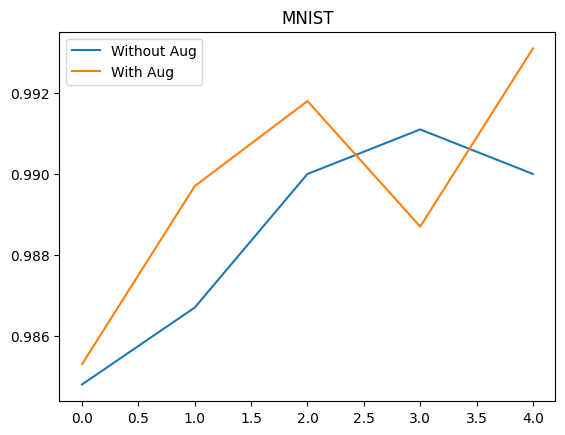

Conclusion: Improved ✅


In [7]:
plt.plot(history1.history['val_accuracy'], label='Without Aug')
plt.plot(history2.history['val_accuracy'], label='With Aug')
plt.legend(); plt.title("MNIST"); plt.show()

print("Conclusion:", "Improved ✅" if max(history2.history['val_accuracy']) > max(history1.history['val_accuracy']) else "No Change ❌")